<a href="https://colab.research.google.com/github/dakshini01/Statistical-Learning-e20181/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression for Building Heating and Cooling Loads

## Objective

The dataset contains eight building-design parameters, denoted by $X_1$ to $X_8$, and two output variables:

- $Y_1$: Heating load
- $Y_2$: Cooling load

The objective is to explore whether the heating load and cooling load can be represented using a **single-parameter Gaussian Process Regression model**.

A direct scalar Gaussian Process model produces only one output value. However, the dataset contains two related outputs. Therefore, the two outputs are first converted into one latent energy-load parameter using Principal Component Analysis (PCA).

Let the standardized output vector be:

$$
\widetilde{\mathbf{Y}}_i =
\begin{bmatrix}
\widetilde{Y}_{1,i} \\
\widetilde{Y}_{2,i}
\end{bmatrix}.
$$

A single latent parameter is defined as:

$$
Z_i = \mathbf{w}^{T}\widetilde{\mathbf{Y}}_i.
$$

Here, $Z_i$ represents the main common variation shared by heating load and cooling load.

The Gaussian Process model is then trained as:

$$
Z = f(X_1, X_2, \ldots, X_8) + \epsilon,
$$

where $f(\cdot)$ is the unknown nonlinear function and $\epsilon$ represents random noise.

After predicting $Z$, the heating load and cooling load are reconstructed using the inverse PCA transformation.

In [1]:
# Install KaggleHub when required
!pip -q install kagglehub

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import kagglehub

# Download the dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

# Read either the CSV or Excel version of the dataset
csv_files = glob.glob(os.path.join(path, "*.csv"))
excel_files = glob.glob(os.path.join(path, "*.xlsx"))

if csv_files:
    df_gp = pd.read_csv(csv_files[0])
elif excel_files:
    df_gp = pd.read_excel(excel_files[0])
else:
    raise FileNotFoundError("No CSV or Excel file was found.")

# Clean the column names and remove completely empty columns
df_gp.columns = df_gp.columns.astype(str).str.strip()
df_gp = df_gp.dropna(axis=1, how="all")

print("Dataset shape:", df_gp.shape)
print("Columns:", df_gp.columns.tolist())

display(df_gp.head())

100%|██████████| 6.22k/6.22k [00:00<00:00, 7.81MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1
Files: ['ENB2012_data.csv']
Dataset shape: (768, 10)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Correlation between heating load and cooling load = 0.9759


,Y1,Y2
count,768.000000,768.000000
mean,22.307201,24.587760
std,10.090196,9.513306
min,6.010000,10.900000
25%,12.992500,15.620000
50%,18.950000,22.080000
75%,31.667500,33.132500
max,43.100000,48.030000


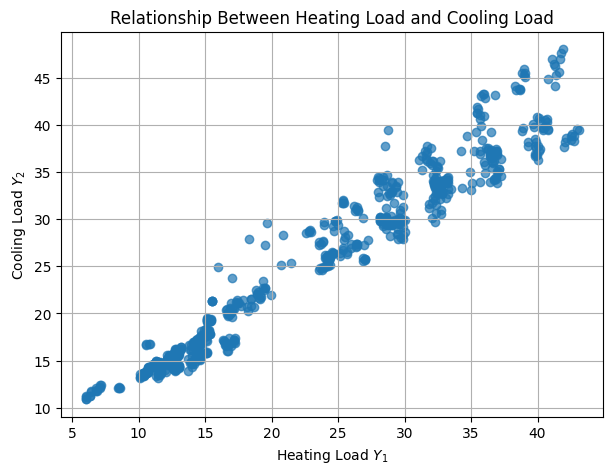

In [2]:
feature_columns = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]
target_columns = ["Y1", "Y2"]

# Keep only the required columns and remove incomplete records
df_gp = df_gp[feature_columns + target_columns].dropna().copy()

# Calculate correlation between heating load and cooling load
target_correlation = df_gp["Y1"].corr(df_gp["Y2"])

print(f"Correlation between heating load and cooling load = {target_correlation:.4f}")

# Display descriptive statistics
display(df_gp[target_columns].describe())

# Plot the relationship
plt.figure(figsize=(7, 5))
plt.scatter(df_gp["Y1"], df_gp["Y2"], alpha=0.7)
plt.xlabel("Heating Load $Y_1$")
plt.ylabel("Cooling Load $Y_2$")
plt.title("Relationship Between Heating Load and Cooling Load")
plt.grid(True)
plt.show()

## Initial Observation

The correlation coefficient between the heating load and the cooling load is calculated using:

$$
r_{Y_1,Y_2}
=
\frac{
\operatorname{Cov}(Y_1,Y_2)
}{
\sigma_{Y_1}\sigma_{Y_2}
}.
$$

A value of $r$ close to $1$ indicates that the two loads usually increase and decrease together.

However, correlation alone is not sufficient to prove that the two outputs can be replaced by one parameter. Therefore, PCA is used to measure how much of the information in $Y_1$ and $Y_2$ can be captured using a single latent variable $Z$.

In [3]:
# Separate inputs and outputs
X = df_gp[feature_columns].copy()
Y = df_gp[target_columns].copy()

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

# X6: orientation and X8: glazing-area distribution are treated as categories
continuous_columns = ["X1", "X2", "X3", "X4", "X5", "X7"]
categorical_columns = ["X6", "X8"]

# Make the code compatible with different scikit-learn versions
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

input_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_columns),
        ("categorical", encoder, categorical_columns)
    ]
)

# Scale and encode the input parameters
X_train_transformed = input_preprocessor.fit_transform(X_train)
X_test_transformed = input_preprocessor.transform(X_test)

# Standardize the two output variables
output_scaler = StandardScaler()
Y_train_scaled = output_scaler.fit_transform(Y_train)

# Reduce Y1 and Y2 into a single latent energy-load parameter Z
pca = PCA(n_components=1)
Z_train = pca.fit_transform(Y_train_scaled).ravel()

explained_variance = pca.explained_variance_ratio_[0]

print(f"Variance captured by the single latent parameter Z = {explained_variance * 100:.2f}%")
print("PCA weights:", pca.components_[0])

# Define the Gaussian Process kernel
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-5, 1.0))
)

# Fit the scalar Gaussian Process model
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    gp_model = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=2,
        random_state=42
    )

    gp_model.fit(X_train_transformed, Z_train)

print("Optimized kernel:")
print(gp_model.kernel_)

Variance captured by the single latent parameter Z = 98.82%
PCA weights: [0.70710678 0.70710678]
Optimized kernel:
1.8**2 * RBF(length_scale=2.12) + WhiteKernel(noise_level=0.0013)


In [4]:
# Predict the latent parameter and its uncertainty
Z_prediction, Z_standard_deviation = gp_model.predict(
    X_test_transformed,
    return_std=True
)

# Reconstruct standardized Y1 and Y2 values from the latent parameter
Y_prediction_scaled = pca.inverse_transform(
    Z_prediction.reshape(-1, 1)
)

# Convert the standardized predictions back to their original units
Y_prediction = output_scaler.inverse_transform(Y_prediction_scaled)

results_gp = []

for index, target in enumerate(target_columns):
    actual = Y_test.iloc[:, index].to_numpy()
    predicted = Y_prediction[:, index]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    results_gp.append({
        "Output": target,
        "Description": "Heating Load" if target == "Y1" else "Cooling Load",
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r2
    })

results_gp = pd.DataFrame(results_gp)

display(results_gp.round(4))

,Output,Description,MAE,RMSE,R-squared
0,Y1,Heating Load,0.9637,1.3879,0.9815
1,Y2,Cooling Load,1.1314,1.6346,0.9712


<>:17: SyntaxWarning: invalid escape sequence '\w'
<>:39: SyntaxWarning: invalid escape sequence '\w'
<>:17: SyntaxWarning: invalid escape sequence '\w'
<>:39: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_5427/697333491.py:17: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel("Predicted Heating Load $\widehat{Y}_1$")
/tmp/ipykernel_5427/697333491.py:39: SyntaxWarning: invalid escape sequence '\w'
  plt.ylabel("Predicted Cooling Load $\widehat{Y}_2$")


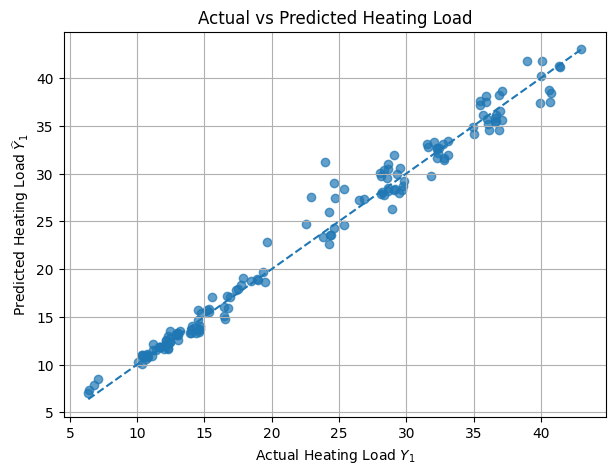

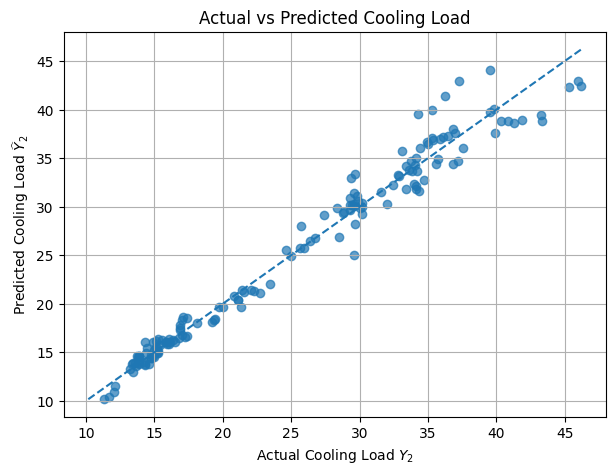

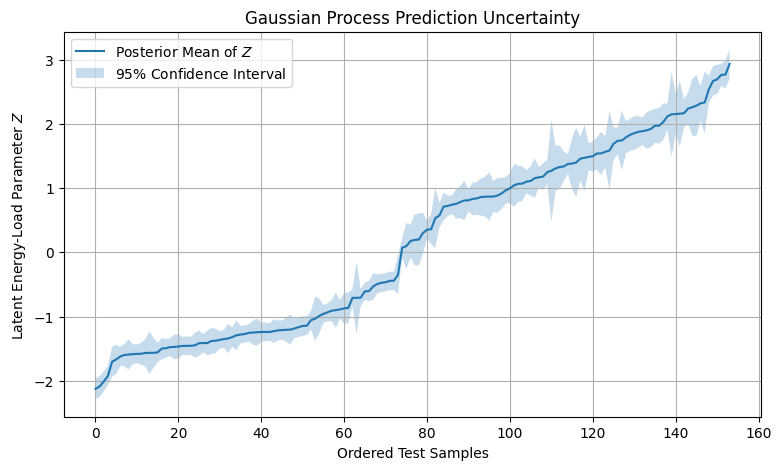

In [5]:
# Heating-load plot
plt.figure(figsize=(7, 5))

actual_heating = Y_test["Y1"].to_numpy()
predicted_heating = Y_prediction[:, 0]

minimum_value = min(actual_heating.min(), predicted_heating.min())
maximum_value = max(actual_heating.max(), predicted_heating.max())

plt.scatter(actual_heating, predicted_heating, alpha=0.7)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)
plt.xlabel("Actual Heating Load $Y_1$")
plt.ylabel("Predicted Heating Load $\widehat{Y}_1$")
plt.title("Actual vs Predicted Heating Load")
plt.grid(True)
plt.show()


# Cooling-load plot
plt.figure(figsize=(7, 5))

actual_cooling = Y_test["Y2"].to_numpy()
predicted_cooling = Y_prediction[:, 1]

minimum_value = min(actual_cooling.min(), predicted_cooling.min())
maximum_value = max(actual_cooling.max(), predicted_cooling.max())

plt.scatter(actual_cooling, predicted_cooling, alpha=0.7)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)
plt.xlabel("Actual Cooling Load $Y_2$")
plt.ylabel("Predicted Cooling Load $\widehat{Y}_2$")
plt.title("Actual vs Predicted Cooling Load")
plt.grid(True)
plt.show()


# Uncertainty plot for the latent parameter Z
order = np.argsort(Z_prediction)
ordered_prediction = Z_prediction[order]
ordered_deviation = Z_standard_deviation[order]

sample_numbers = np.arange(len(ordered_prediction))

plt.figure(figsize=(9, 5))
plt.plot(sample_numbers, ordered_prediction, label="Posterior Mean of $Z$")
plt.fill_between(
    sample_numbers,
    ordered_prediction - 1.96 * ordered_deviation,
    ordered_prediction + 1.96 * ordered_deviation,
    alpha=0.25,
    label="$95\\%$ Confidence Interval"
)
plt.xlabel("Ordered Test Samples")
plt.ylabel("Latent Energy-Load Parameter $Z$")
plt.title("Gaussian Process Prediction Uncertainty")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
heating_r2 = results_gp.loc[
    results_gp["Output"] == "Y1",
    "R-squared"
].iloc[0]

cooling_r2 = results_gp.loc[
    results_gp["Output"] == "Y2",
    "R-squared"
].iloc[0]

if explained_variance >= 0.95:
    latent_conclusion = (
        "The first principal component captures almost all of the common variation "
        "in the two outputs. Therefore, the single latent parameter provides a "
        "reasonable compact representation of the overall building energy-load behaviour."
    )
else:
    latent_conclusion = (
        "The first principal component does not capture enough of the total variation. "
        "Therefore, one latent parameter may discard important differences between "
        "heating load and cooling load."
    )

display(Markdown(f"""
## Gaussian Process Regression: Discussion and Conclusion

The calculated correlation between heating load and cooling load is:

$$
r_{{Y_1,Y_2}} = {target_correlation:.4f}.
$$

The first principal component captures:

$$
{explained_variance * 100:.2f}\\%
$$

of the total standardized variation in $Y_1$ and $Y_2$.

The scalar Gaussian Process was trained using the latent parameter:

$$
Z = \\mathbf{{w}}^T \\widetilde{{\\mathbf{{Y}}}}.
$$

The reconstructed heating-load model achieved:

$$
R^2_{{\\text{{heating}}}} = {heating_r2:.4f}.
$$

The reconstructed cooling-load model achieved:

$$
R^2_{{\\text{{cooling}}}} = {cooling_r2:.4f}.
$$

{latent_conclusion}

A single-parameter Gaussian Process is useful when the objective is to obtain
one compact indicator of the general thermal-energy requirement of a building.
It also reduces the complexity of the model.

However, the model should not be interpreted as a perfect replacement for
two separate output models. Heating load and cooling load are strongly related,
but they are not identical. Some information is lost when the second principal
component is removed.

Therefore, a single latent-output Gaussian Process is suitable for summarizing
overall energy-load behaviour. If highly accurate individual predictions of
heating load and cooling load are required, two separate Gaussian Process
models or a true multivariate-output Gaussian Process model would be more suitable.
"""))


## Gaussian Process Regression: Discussion and Conclusion

The calculated correlation between heating load and cooling load is:

$$
r_{Y_1,Y_2} = 0.9759.
$$

The first principal component captures:

$$
98.82\%
$$

of the total standardized variation in $Y_1$ and $Y_2$.

The scalar Gaussian Process was trained using the latent parameter:

$$
Z = \mathbf{w}^T \widetilde{\mathbf{Y}}.
$$

The reconstructed heating-load model achieved:

$$
R^2_{\text{heating}} = 0.9815.
$$

The reconstructed cooling-load model achieved:

$$
R^2_{\text{cooling}} = 0.9712.
$$

The first principal component captures almost all of the common variation in the two outputs. Therefore, the single latent parameter provides a reasonable compact representation of the overall building energy-load behaviour.

A single-parameter Gaussian Process is useful when the objective is to obtain
one compact indicator of the general thermal-energy requirement of a building.
It also reduces the complexity of the model.

However, the model should not be interpreted as a perfect replacement for
two separate output models. Heating load and cooling load are strongly related,
but they are not identical. Some information is lost when the second principal
component is removed.

Therefore, a single latent-output Gaussian Process is suitable for summarizing
overall energy-load behaviour. If highly accurate individual predictions of
heating load and cooling load are required, two separate Gaussian Process
models or a true multivariate-output Gaussian Process model would be more suitable.


# Linear Regression for Predicted Energy Demand

## Objective

The objective is to explore whether `predicted_energy_demand` can be estimated using a linear relationship with a suitable set of building and energy-related variables.

The linear-regression model is written as:

$$
Y =
\beta_0
+
\beta_1 X_1
+
\beta_2 X_2
+
\cdots
+
\beta_p X_p
+
\epsilon,
$$

where:

- $Y$ is the predicted energy demand,
- $\beta_0$ is the intercept,
- $\beta_1$ to $\beta_p$ are regression coefficients,
- $X_1$ to $X_p$ are selected predictor variables,
- $\epsilon$ is the unexplained random error.

The following parameters are initially selected because they have a clear physical relationship with building energy demand:

- `ventilation_rate`
- `equipment_load`
- `heating_energy`
- `cooling_energy`
- `electricity_consumption`
- `occupancy`

Ventilation affects the energy required to condition incoming air. Equipment load and occupancy influence the internal energy use of the building. Heating energy, cooling energy and electricity consumption are direct energy-related measurements.

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import kagglehub

# Download the dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

csv_files = glob.glob(os.path.join(path, "*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV file was found.")

df_lr = pd.read_csv(csv_files[0])

# Clean column names
df_lr.columns = df_lr.columns.astype(str).str.strip()

print("Dataset shape:", df_lr.shape)
print("Columns:", df_lr.columns.tolist())

display(df_lr.head())

100%|██████████| 347k/347k [00:00<00:00, 16.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/programmer3/green-building-multi-source-environment-dataset/versions/1
Files: ['green_building_dataset.csv']
Dataset shape: (2400, 19)
Columns: ['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


Selected predictor variables:
- ventilation_rate
- equipment_load
- heating_energy
- cooling_energy
- electricity_consumption
- occupancy


,Correlation with predicted energy demand
ventilation_rate,0.7289
electricity_consumption,0.3987
cooling_energy,0.3706
heating_energy,0.2713
equipment_load,0.0588
occupancy,0.0577


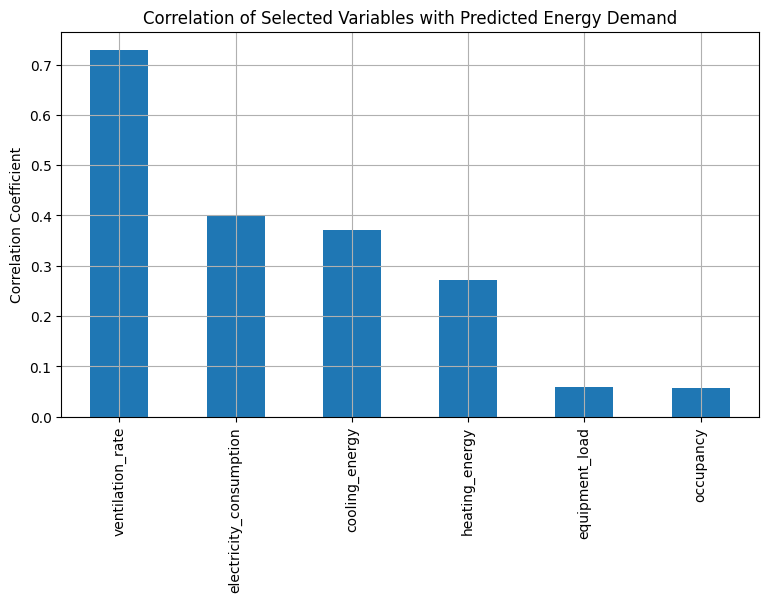

In [9]:
target = "predicted_energy_demand"

preferred_features = [
    "ventilation_rate",
    "equipment_load",
    "heating_energy",
    "cooling_energy",
    "electricity_consumption",
    "occupancy"
]

# Use the preferred physically meaningful variables when available
selected_features = [
    feature for feature in preferred_features
    if feature in df_lr.columns
]

# Fallback method in case the dataset column names are changed
if len(selected_features) < 2:
    print("Some preferred columns were not found.")
    print("Selecting the six numeric variables with the strongest correlations.")

    numeric_df = df_lr.select_dtypes(include=np.number)

    correlations = (
        numeric_df.corr()[target]
        .drop(target)
        .abs()
        .sort_values(ascending=False)
    )

    selected_features = correlations.head(6).index.tolist()

print("Selected predictor variables:")
for feature in selected_features:
    print("-", feature)

# Convert required columns into numeric values and remove incomplete records
data_lr = df_lr[selected_features + [target]].copy()

for column in data_lr.columns:
    data_lr[column] = pd.to_numeric(data_lr[column], errors="coerce")

data_lr = data_lr.dropna()

# Display correlations with the target
correlations_with_target = (
    data_lr.corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(
    correlations_with_target
    .rename("Correlation with predicted energy demand")
    .to_frame()
    .round(4)
)

# Plot correlation strengths
plt.figure(figsize=(9, 5))
correlations_with_target.plot(kind="bar")
plt.ylabel("Correlation Coefficient")
plt.title("Correlation of Selected Variables with Predicted Energy Demand")
plt.grid(True)
plt.show()

In [10]:
X = data_lr[selected_features]
y = data_lr[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardization allows the coefficient sizes to be compared fairly
linear_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("regression", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_prediction = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_prediction)
rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
r2 = r2_score(y_test, y_prediction)

# Cross-validation
cv_r2_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(f"Mean Absolute Error (MAE) = {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) = {rmse:.4f}")
print(f"Test R-squared = {r2:.4f}")
print(f"Mean 5-fold cross-validation R-squared = {cv_r2_scores.mean():.4f}")
print(f"Cross-validation standard deviation = {cv_r2_scores.std():.4f}")

Mean Absolute Error (MAE) = 1.4954
Root Mean Squared Error (RMSE) = 1.9014
Test R-squared = 0.9613
Mean 5-fold cross-validation R-squared = 0.9535
Cross-validation standard deviation = 0.0044


In [11]:
scaler = linear_model.named_steps["scaler"]
regression = linear_model.named_steps["regression"]

# Standardized coefficients
standardized_coefficients = regression.coef_

# Convert the coefficients back to the original units
original_coefficients = regression.coef_ / scaler.scale_

original_intercept = (
    regression.intercept_
    - np.dot(original_coefficients, scaler.mean_)
)

coefficient_table = pd.DataFrame({
    "Feature": selected_features,
    "Correlation with Target": [
        data_lr[feature].corr(data_lr[target])
        for feature in selected_features
    ],
    "Standardized Coefficient": standardized_coefficients,
    "Original-Unit Coefficient": original_coefficients
})

coefficient_table["Absolute Standardized Coefficient"] = (
    coefficient_table["Standardized Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute Standardized Coefficient",
    ascending=False
)

display(coefficient_table.round(5))

# Construct the fitted equation
equation_terms = [
    f"({coefficient:.4f})({feature})"
    for feature, coefficient
    in zip(selected_features, original_coefficients)
]

fitted_equation = (
    f"$\\widehat{{Y}} = {original_intercept:.4f} + "
    + " + ".join(equation_terms)
    + "$"
)

display(Markdown("## Fitted Linear Equation"))
display(Markdown(fitted_equation))

,Feature,Correlation with Target,Standardized Coefficient,Original-Unit Coefficient,Absolute Standardized Coefficient
0,ventilation_rate,0.72887,7.18698,0.05002,7.18698
4,electricity_consumption,0.39870,4.17384,0.29314,4.17384
3,cooling_energy,0.37063,3.57288,0.25024,3.57288
2,heating_energy,0.27130,2.86635,0.24902,2.86635
1,equipment_load,0.05877,0.82489,0.09523,0.82489
5,occupancy,0.05766,0.66521,0.04571,0.66521


## Fitted Linear Equation

$\widehat{Y} = 0.2922 + (0.0500)(ventilation_rate) + (0.0952)(equipment_load) + (0.2490)(heating_energy) + (0.2502)(cooling_energy) + (0.2931)(electricity_consumption) + (0.0457)(occupancy)$

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Standardize the predictors before calculating VIF
X_standardized = StandardScaler().fit_transform(data_lr[selected_features])

vif_table = pd.DataFrame({
    "Feature": selected_features,
    "VIF": [
        variance_inflation_factor(X_standardized, index)
        for index in range(X_standardized.shape[1])
    ]
})

display(vif_table.sort_values("VIF", ascending=False).round(4))

,Feature,VIF
0,ventilation_rate,1.0038
1,equipment_load,1.0027
4,electricity_consumption,1.0024
5,occupancy,1.0017
2,heating_energy,1.0015
3,cooling_energy,1.0009


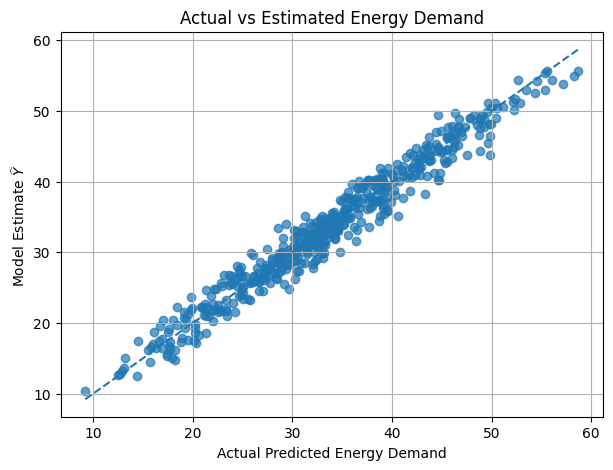

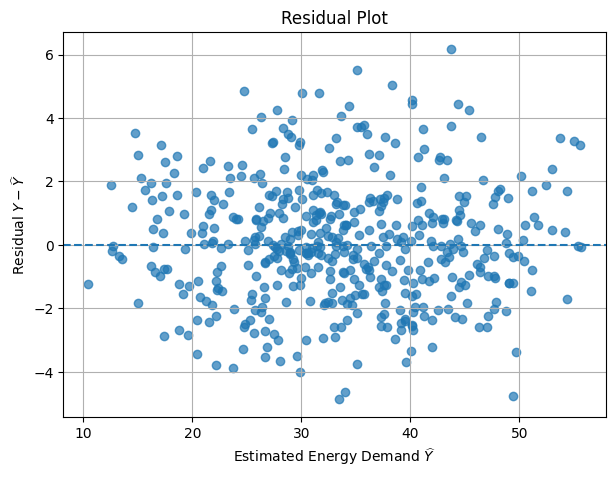

In [13]:
# Actual vs predicted values
plt.figure(figsize=(7, 5))

minimum_value = min(y_test.min(), y_prediction.min())
maximum_value = max(y_test.max(), y_prediction.max())

plt.scatter(y_test, y_prediction, alpha=0.7)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)
plt.xlabel("Actual Predicted Energy Demand")
plt.ylabel("Model Estimate $\\widehat{Y}$")
plt.title("Actual vs Estimated Energy Demand")
plt.grid(True)
plt.show()


# Residual plot
residuals = y_test - y_prediction

plt.figure(figsize=(7, 5))
plt.scatter(y_prediction, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Estimated Energy Demand $\\widehat{Y}$")
plt.ylabel("Residual $Y - \\widehat{Y}$")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [14]:
import statsmodels.api as sm

X_with_constant = sm.add_constant(data_lr[selected_features])

ols_model = sm.OLS(
    data_lr[target],
    X_with_constant
).fit()

print(ols_model.summary())

                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.954
Model:                                 OLS   Adj. R-squared:                  0.954
Method:                      Least Squares   F-statistic:                     8302.
Date:                     Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                             16:58:08   Log-Likelihood:                -5124.2
No. Observations:                     2400   AIC:                         1.026e+04
Df Residuals:                         2393   BIC:                         1.030e+04
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [15]:
maximum_vif = vif_table["VIF"].max()

if r2 >= 0.90:
    prediction_quality = (
        "The linear model explains a very high proportion of the variation in "
        "the target variable. Therefore, a linear relationship is suitable for "
        "predicting energy demand in this dataset."
    )
elif r2 >= 0.70:
    prediction_quality = (
        "The model explains a substantial proportion of the variation in the "
        "target variable. The linear approximation is useful, although nonlinear "
        "models may improve the prediction accuracy."
    )
else:
    prediction_quality = (
        "The linear model leaves a considerable amount of variation unexplained. "
        "Therefore, a nonlinear model should also be investigated."
    )

if maximum_vif > 10:
    vif_comment = (
        "Some predictors have high Variance Inflation Factor values. This indicates "
        "multicollinearity. The model may still provide good predictions, but the "
        "individual regression coefficients should be interpreted carefully."
    )
else:
    vif_comment = (
        "The VIF values do not indicate severe multicollinearity among the selected predictors."
    )

feature_list = ", ".join(
    [f"`{feature}`" for feature in selected_features]
)

display(Markdown(f"""
## Linear Regression: Discussion and Conclusion

The selected predictor variables are:

{feature_list}.

These variables were selected because they have physically meaningful
relationships with energy demand. The correlation table was also used to
verify that they contain useful information for predicting the target.

The fitted model follows the form:

$$
\\widehat{{Y}}
=
\\widehat{{\\beta}}_0
+
\\sum_{{j=1}}^{{p}}
\\widehat{{\\beta}}_j X_j.
$$

The test-set performance values are:

$$
\\operatorname{{MAE}} = {mae:.4f},
$$

$$
\\operatorname{{RMSE}} = {rmse:.4f},
$$

and:

$$
R^2 = {r2:.4f}.
$$

The mean five-fold cross-validation result is:

$$
\\overline{{R^2_{{\\mathrm{{CV}}}}}} = {cv_r2_scores.mean():.4f}.
$$

{prediction_quality}

{vif_comment}

The residual plot should be inspected carefully. If the residual values are
randomly scattered around $0$, the linear model is reasonable. A visible
curved pattern would suggest that an important nonlinear relationship has
not been captured.

A final limitation must also be considered. Variables such as
`heating_energy`, `cooling_energy` and `electricity_consumption` may be
directly related to the method used to calculate `predicted_energy_demand`.
If the target was created using these variables, the fitted model is useful
for reconstructing the target but should not automatically be treated as an
independent forecasting model. For a real forecasting application, the
predictors must be values that are available before the future energy demand
is observed.
"""))


## Linear Regression: Discussion and Conclusion

The selected predictor variables are:

`ventilation_rate`, `equipment_load`, `heating_energy`, `cooling_energy`, `electricity_consumption`, `occupancy`.

These variables were selected because they have physically meaningful
relationships with energy demand. The correlation table was also used to
verify that they contain useful information for predicting the target.

The fitted model follows the form:

$$
\widehat{Y}
=
\widehat{\beta}_0
+
\sum_{j=1}^{p}
\widehat{\beta}_j X_j.
$$

The test-set performance values are:

$$
\operatorname{MAE} = 1.4954,
$$

$$
\operatorname{RMSE} = 1.9014,
$$

and:

$$
R^2 = 0.9613.
$$

The mean five-fold cross-validation result is:

$$
\overline{R^2_{\mathrm{CV}}} = 0.9535.
$$

The linear model explains a very high proportion of the variation in the target variable. Therefore, a linear relationship is suitable for predicting energy demand in this dataset.

The VIF values do not indicate severe multicollinearity among the selected predictors.

The residual plot should be inspected carefully. If the residual values are
randomly scattered around $0$, the linear model is reasonable. A visible
curved pattern would suggest that an important nonlinear relationship has
not been captured.

A final limitation must also be considered. Variables such as
`heating_energy`, `cooling_energy` and `electricity_consumption` may be
directly related to the method used to calculate `predicted_energy_demand`.
If the target was created using these variables, the fitted model is useful
for reconstructing the target but should not automatically be treated as an
independent forecasting model. For a real forecasting application, the
predictors must be values that are available before the future energy demand
is observed.


# Overall Conclusion

For the Gaussian Process Regression analysis, heating load and cooling load
are strongly related. PCA is used to combine them into one latent variable
$Z$. The percentage of variance captured by the first principal component
shows whether a single-parameter Gaussian Process is an acceptable
approximation.

The single latent-output Gaussian Process is suitable when one compact
energy-load indicator is required. However, separate models or a
multivariate-output Gaussian Process should be used when highly accurate
individual heating-load and cooling-load predictions are required.

For the linear-regression analysis, a suitable set of physically meaningful
predictors is selected and evaluated using $R^2$, MAE, RMSE, cross-validation
and residual analysis. The suitability of the linear relationship depends on
the calculated model results and the absence of a clear pattern in the
residual plot.